In [ ]:
# Librerias:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot') #estilo de las gráficas
from scipy.optimize import fsolve

 # Entropia en economía


En economía, la entropía se puede definir como todas las posibles formas en las que los bienes, dinero y servicios se pueden distribuir entre los agentes (agentes: personas, empresas, gobiernos, instituciones financieras, entre otras).

## Numero de microestados $\Omega$
Todas las formas de distribuir $N$ elementos en K categorias, dadas ciertas cantidades $N_1,N_2,\dots$

Fórmula combinatoria:

$$
\Omega = \frac{N!}{N_1! \cdot N_2! \cdot \cdots \cdot N_K!} \tag{1}
$$

* $N!$: Permutaciones totales de los $N$ elementos (si fueran distintos).
* $N_i!$: Corrige la sobrecontabilización, ya que los elementos dentro de una misma categoría se consideran indistinguibles.
* $N_i$: Son el número de elementos (recursos, agentes, bienes, etc.) asignados a dos categorías diferentes en un sistema económico. Estas categorías pueden ser cualquier par de variables que influyan en la diversidad o equilibrio del sistema




## Fracción relativa ó número relativo ($x_i$)

$x_i$ es la **proporción de elementos en la categoría** $i$ respecto al total $N$:

$$
x_i = \frac{N_i}{N}, \quad \text{donde} \quad \sum_{i=1}^{K} x_i = 1.
$$

 **Ejemplo:**

 Si $N = 10$ y $N_1 = 4$, entonces $x_1 = \frac{4}{10} = 0.4$.



- Probabilidad de una configuración específica

* La probabilidad de observar una distribución particular $\{N_1, N_2, \ldots, N_K\}$ es:

$$
P_{\{N_i\}} = \Omega \cdot \prod_{i=1}^{K} (x_i)^{N_i}
$$

**Interpretación:**
- $\Omega$: Número de formas de lograr la distribución $\{N_i\}$.
- $\prod_{i=1}^{K} (x_i)^{N_i}$: Probabilidad de que cada elemento caiga en su categoría asignada, asumiendo independencia.


## Demostración
La entropía en economía se define como: $$S_e = \ln (\Omega) \tag{2}$$
En este caso, remplazamos la ecuación 1 en la ecuación 2, quedandonos:

$$S_e = \ln(N!) - \ln \left( \prod_{i=1}^{K} N_i ! \right) \tag{3}$$

* En termodinámica utilizamos una aproximación para cuando $N$ es muy grande, la cual se conoce como la aproximación de stirling: $$\ln(N!) = N\ln (N) - N \tag{4}$$

* Vamos a utilizar esta la ecuación 4 en 3 y también, vamos a utilizar la propiedad $\ln(\prod N) = \sum \ln(N)$: $$S_e = N\ln(N) - N - \sum_{i=1} ^K \ln (N_i !)$$
    * volvemos a aplicar la ecuacion 4 $$S_e = N\ln(N) - N - \sum_{i=1} ^K N_i \ln (N_i) + \sum_{i=1} ^K N_i $$
    * por definicion sabemos que $\sum_{i=1} ^K N_i = N$. Haciendo este remplazmo nos queda que:

    $$ \boxed{S_e = N\ln(N) - \sum_{i=1} ^K N_i \ln (N_i)} \tag{5}$$

* La ecuación 5 la podemos simplificar aun más aplicando el concepto de fracción relativa $x_i$. Para hacer esto primero, remplazamos en 5 $N= \sum_{i=1} ^K N_i $, quedando: $$S_e = \sum_{i=1} ^K N_i\ln(N) - \sum_{i=1} ^K N_i \ln (N_i) $$
    * multiplicamos toda la ecuacion por $\frac{N}{N}$, lo que nos queda como: $$S_e = N \left(\sum_{i=1} ^K \frac{N_i}{N} \ln(N) - \sum_{i=1} ^K \frac{N_i}{N} \ln (N_i) \right)$$
    * por definicion sabemos que:
        * $\frac{N_i}{N} = x_i$
        * $\ln(a) - ln(b) = -\ln \left(\frac{b}{a} \right)$
    * remplazamos esto en la ecuación, lo que nos queda al final:
$$\boxed{S_e = -N \sum_{i=1} ^K x_i \ln (x_i)} \tag {6}$$




## Caso de uso

Considermos un sistema de dos elementos distintos: $N_1 \wedge N_2$, en donde definimos $N= N_1 + N_2$. $N_1$ y $N_2$ pueden ser diferentes categorías, como por ejemplo:
  * Distribución de mano de obra en una empresa
    * $N_1$: Número de trabajadores no calificados (ej: operarios).
    * $N_2$: Número de trabajadores calificados (ej: ingenieros).
  
  * Asignación de presupuesto
    * $N_1$: Fondos destinados a marketing.
    * $N_2$: Fondos destinados a investigación y desarrollo (I+D).
  
  * Cartera de inversiones
    * $N_1$: Cantidad invertida en bonos estables.
    * $N_2$: Cantidad invertida en acciones de alto riesgo.

Para este caso, aplicando la ecuación 5, nos queda: $$S_e (N_1, N_2) = N\ln(N) - N_1 \ln(N_1) - N_2 \ln(N_2) \tag{7}$$
* Si queremos verlo con el número relativo, el cual:
    * $x = \frac{N_1}{N}$
    * $1-x = \frac{N_2}{N}$, ya que recordemos que $\sum_{i=1} ^K x_i = 1$
* Con estos valores, remplazamos en la ecuación 6 y nos queda:
    $$S_e = -N\left( x\ln x + (1-x) \ln(1-x) \right) \tag{8}$$

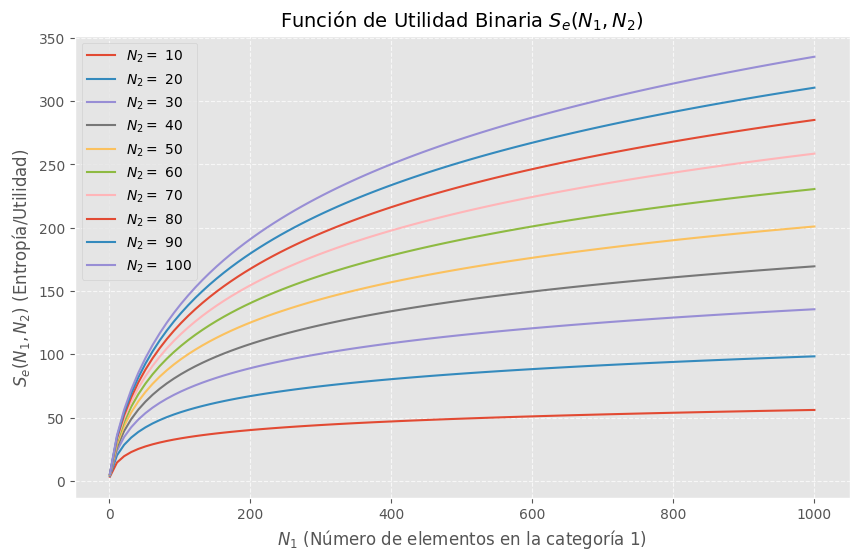

In [ ]:
 #configuramos los nuevos parámetros

# Definir la función de entropía binaria
def binary_entropy(N1, N2):
    N = N1 + N2
    if N1 <= 0 or N2 <= 0 or N <= 0:
        return 0  # Evitar log(0) o valores negativos
    return N * np.log(N) - N1 * np.log(N1) - N2 * np.log(N2)

# Valores fijos de N2 para cada curva
N2_values = [10, 20, 30,40,50,60,70,80,90,100]  # Ejemplo: N2 = 10, 20, 30
N1_range = np.linspace(1, 1000, 100)  # N1 varía de 1 a 1000

# Crear la gráfica
plt.figure(figsize=(10, 6))

for N2 in N2_values:
    S_e = [binary_entropy(N1, N2) for N1 in N1_range]
    plt.plot(N1_range, S_e, label=f'$N_2 =$ {N2}')

plt.xlabel('$N_1$ (Número de elementos en la categoría 1)', fontsize=12)
plt.ylabel('$S_e(N_1, N_2)$ (Entropía/Utilidad)', fontsize=12)
plt.title('Función de Utilidad Binaria $S_e(N_1, N_2)$', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

 **Interpretación de la gráfica**
* En el caso para que sea un maximo, tenemos que $N_1 = N_2$. Sin embargo, en la gráfica este no es el máximo de la curva. Esto es porque $N_1$ va cambiando, lo que hace que $N$ no esté fijo, por lo que el valor de $x$ va a cambiar dinámicamente

- **Crecimiento sublineal:**
  * Nosotros tenemos definida la funcion (utilidad binaria), la cual mide la diversidad en sistemas con dos categorias, como: $$S_e(N_1,N_2) = N \ln(N) -N_1 \ln(N_1) - N_2 \ln(N_2) \tag{9}$$
  * Ahora analicemos la derivada de la ecuación 9 con respecto a $N_1$ con $N_2$ fijo, la cual llamaremos como **beneficio marginal**, la cual se define como el incremento en la utilidad total que se obtiene al añadir una nueda unidad adicional del recurso (en este caso por ejemplo, trabajadores)
  * si analizamos esto vemos que nos queda de la forma: $$\frac{\partial S_e}{\partial N_1} = \ln \left(\frac{N}{N_1}\right)$$
  * Obsrevamos que cuando $N_1 << N$, vemos que $\frac{N}{N_1}$ es muy grande. A medida que $N_1$ aumenta, la pendiente disminuye, lo que nos confirma un crecimiento sublineal, es decir, crece pero más lento que una lineal.
  * Esto refleja **rendimientos decrecientes**:
    * un rendimiento decreciente es cuando por cada unidad adicional (cuando hablamos de unidad podemos decir por ejemplo un trabajador), aporta un beneficio menor que el anterior. Por lo tanto en este caso contratar más trabajadores calificados aumenta la utilidad, pero su contribución marginal disminuye.

- **Efecto de $N_2$:**
  * Curvas con $N_2$ más alto están desplazadas hacia arriba, ya que un mayor $N_2$ incrementa el número total $N$
  * Al mantener $N_2$ fijo y variar $N_1$, el total $N = N_1 + N_2$ crece con $N_1$. Sin embargo, si comparamos curvas con distintos valores fijos de $N_2$, un $N_2$ mayor implica un $N$ más grande **para el mismo** $N_1$.
  - **Ejemplo:**
    - Si $N_2 = 10$ y $N_1 = 50$, entonces $N = 60$.
    - Si $N_2 = 20$ y $N_1 = 50$, entonces $N = 70$.

  * Por lo tanto, un $N_2$ mayor eleva $S_e$ incluso para el mismo $N_1$. un $N_2$ mayor también implica más combinaciones permitidas de los elementos

## Maximización de la funcion de utilidad para el ejemplo 1
* En el caso para que sea un maximo, tenemos que $N_1 = N_2$.
* Para encontrar el máximo en este caso, primero tomemos la ecuación 8 y la derivamos con respecto a $x$: $$\frac{dS_e}{dx} *\frac{1}{N} = -\ln x - 1 + \ln(1-x) +1 = -\ln \left(\frac{x}{1-x} \right) \tag{10}$$
  * igualamos la ecuación 10 a 0 para encontrar el punto crítico: $$\ln \left(\frac{x}{1-x} \right) = 0$$
  * elevamos a la $e$ la expresion y nos da que:
  $$\frac{x}{1-x} = 1 ⟶ \therefore x= \frac{1}{2}=0.5 \tag{11}$$

* Por la definicion de fracción relativa en este caso particular, sabemos que: $$x = \frac{N_1}{N}$$
  * remplazamos la ecuación 11 y la definición de $N=N_1 + N_2$: $$0.5 = \frac{N_1}{N_1 + N_2}$$

   $$\therefore N_1 = N_2 \tag{12}$$



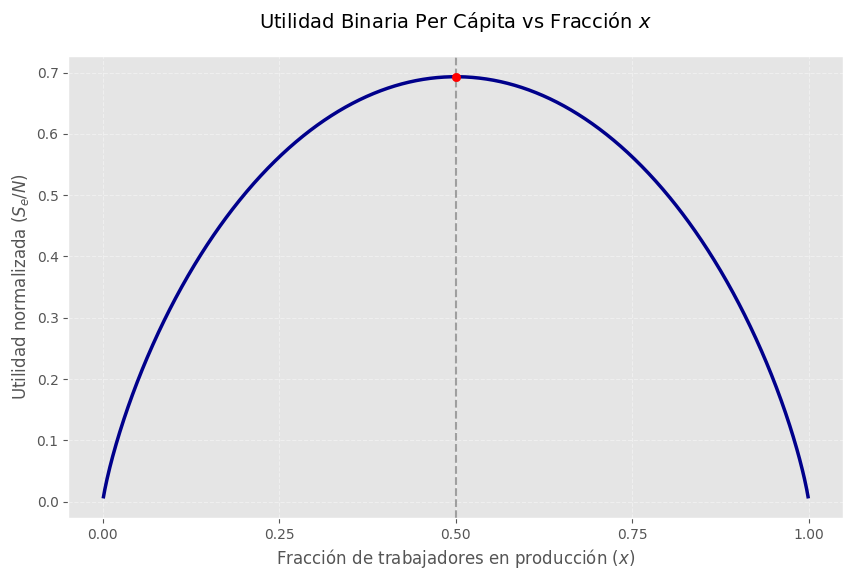

In [ ]:

 #configuramos los nuevos parámetros

# Definir la función de utilidad per cápita (entropía normalizada)
def normalized_utility(x):
    # Evitar log(0) en los extremos
    epsilon = 1e-10 # numero pequeño cercano a 0
    x = np.clip(x, epsilon, 1 - epsilon) # recorta los calores de x, para que estén entre [epsilon, 1-epsilon]
    return - (x * np.log(x) + (1 - x) * np.log(1 - x))

# Generar datos
x = np.linspace(0.001, 0.999, 1000)  # array de 1000 elementos, entre 0.001 y 0.999
utility = normalized_utility(x)   #utilizamos la funcion que definimos previamente
# en este caso, nos da el Se/N, para que no se nos modifique el valor por el tamaño de la poblacion
# Por eso la llamamos "normalizada", ya que evitamos que la N nos modique el valor

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(x, utility, color='darkblue', linewidth=2.5, label=r'$S_e/N = -[x \ln x + (1-x)\ln(1-x)]$')

# Marcar el máximo en x = 0.5
max_x = 0.5
max_utility = normalized_utility(max_x)
plt.scatter(max_x, max_utility, color='red', zorder=5, label='Máximo en $x = 1/2$')
plt.axvline(max_x, color='gray', linestyle='--', alpha=0.7)

# Configuración visual
plt.title('Utilidad Binaria Per Cápita vs Fracción $x$', fontsize=14, pad=20)
plt.xlabel('Fracción de trabajadores en producción ($x$)', fontsize=12)
plt.ylabel('Utilidad normalizada ($S_e / N$)', fontsize=12)
plt.xticks([0, 0.25, 0.5, 0.75, 1], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

* En esta simulación podemos observar que la función de utilidad va aumentando hasta cierto punto. Este punto es el máximo que, como encontramos en la ecuación 11, el máximo de la función de utilidad se da cuando $x=0.5$. En este punto, para nuestro caso que sería la cantidad de trabajadores en dos categorías (ventas y producción), en este punto máximo se alcanza el equilibrio entre ventas y producción
* También vemos que es una curva simétrica, por lo que ambas categorías son importantes, no hay ninguna que sea más pesada que la otra
* Una mayor entropía implica una distribución más equilibrada de recursos, lo que puede traducirse en mayor estabilidad o productividad.
* En el caso extremo, vemos que la función de utilidad vale 0, es decir, la entropía es 0 y por lo tanto, todos los elementos (en nuestro caso número de trabajadores) van a estar en una sola categoría, lo que no permíte una diversidad de distribuciones posibles. Esto es malo para la empresa porque:
  * **Caso de todos los trabajadores en producción**
    * **Falta de ventas:** Aunque se produzca mucho, no hay trabajadores para vender los productos.
    * **Excedentes no vendidos:** Los bienes se acumulan sin generar ingresos.
    * **Colapso financiero:** Sin ventas, no hay ingresos y la empresa 💀.
  
  * **Caso de todos los trabajadores en ventas**
    * **Falta de producción:** No hay bienes o servicios para vender.
    * **Pérdida de clientes:** La empresa no puede cumplir con la demanda, dañando su reputación.
    * **Colapso financiero**: Sin productos, no se puede vender y la empresa 😵



## Optimización con restricciones

El objetivo es responder la pregunta: **¿qué combinación es la óptima para la producción?**.

 Para abordar esta pregunta de manera rigurosa, hacemos una formulación matemática usando los multiplicadores de Lagrange.




**Multiplicadores de Lagrange**:

recordemos que es una herramienta matemática para encontrar el valor óptimo del multiplicador de Lagrange $λ$ de manera que se minimice o maximice una función $f$ bajo una o más restricciones.

Formulación matemática:

$$ 𝓛(x,λ) = f(x) +λg(x)  $$

Para hallar los puntos estacionarios se debe derivar e igualar a cero. Obtenemos la siguiente ecuación:


$$ \frac{∂𝓛}{∂x} + \lambda \frac{∂g(x)}{∂\lambda} = 0 $$ con $$ g(x) = 0 $$


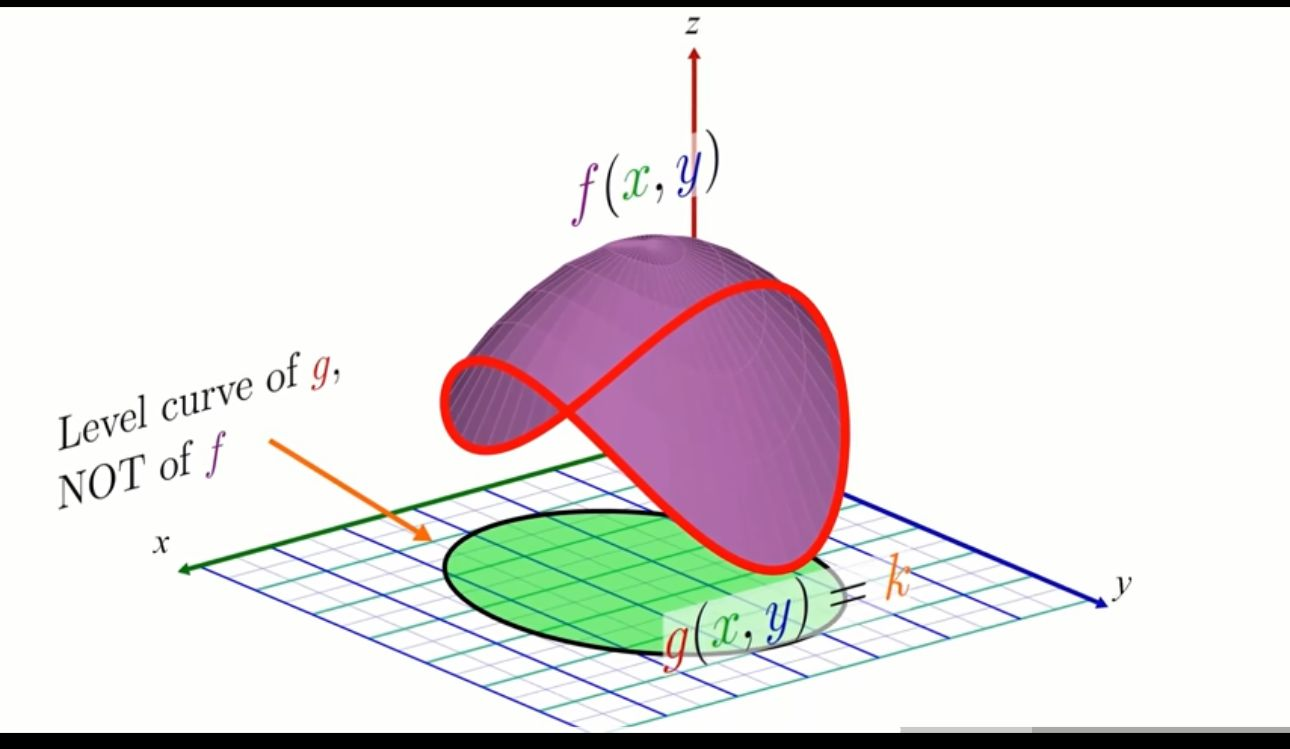




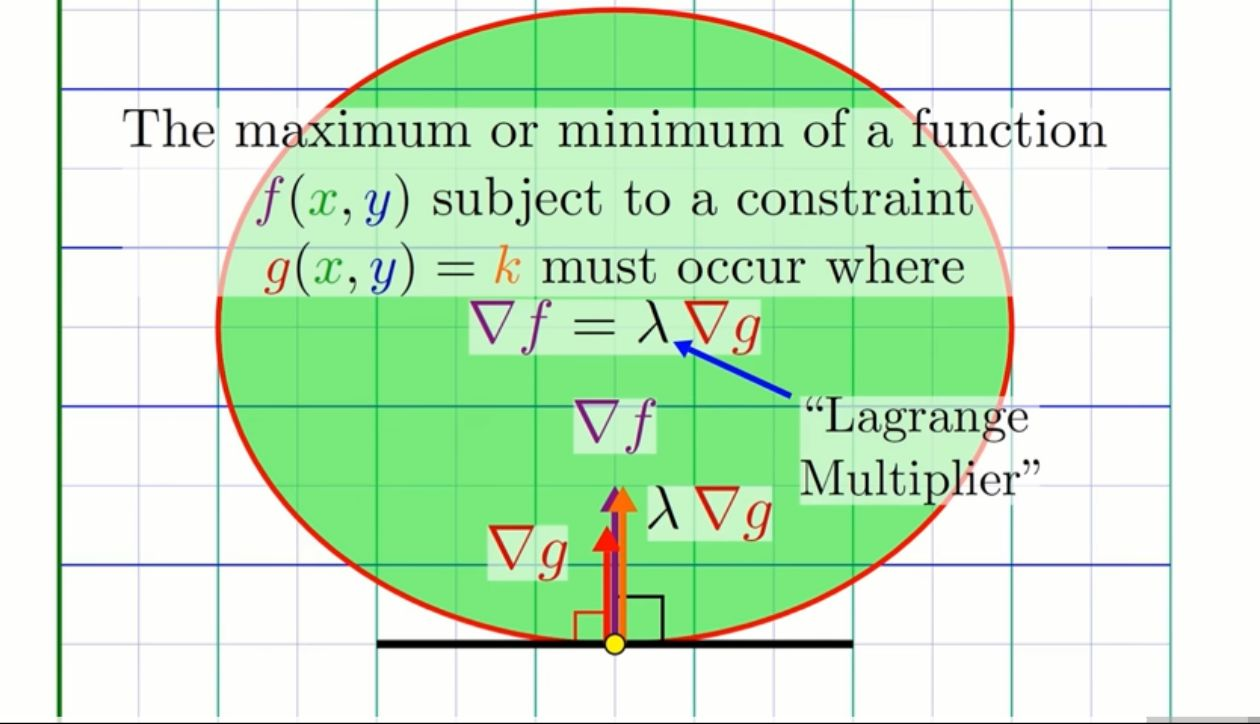



Esta condición se puede generalizar para que la condición tenga la posibilidad de ser una desigualdad. En el siguiente link puede encontrar mas información respecto a esto: [link text](https://en.wikipedia.org/wiki/Karush%E2%80%93Kuhn%E2%80%93Tucker_conditions) (KKT condition)

En nuestro caso de estudio el lagrangiano estará dado por:

$$ 𝓛({N_i},m_l) = c({N_i}) -m_L S_e({N_i})  $$
En donde:
  * $c({N_i})$ Es la función de costo a minimizar.
  * $S_e({N_i})$ Es la restriccion (la máxima función de utilidad).
  * $m_L$ Es el multiplicador de Lagrange a encontrar.

  De manera análoga, en termodinámica este lagrangiano puede ser interpretado como **la energía libre de Hemholtz**: $ F = U - TS $

Problema a optimizar: queremos minimizar la función de costo (pago a los trabajadores) de una compañia que tiene 2 tipos de contratos diferentes:
* $N_1$: trabajadores con contrato fijo y salario $C_1$
* $N_2$: trabajadores con contrato temporal y salario $C_2$

Así, la función de costo simple está dada por: $ C = N_1C_1 + N_2C_2 $

La función de utilidad la hallamos usando la entropía de Shannon

$$ S = - \sum_{i=1}^{k} P_i ln (P_1)  $$
 donde
 $$ P_i = \frac{N_i}{N}, N =N_1 + N_2$$

 Así, el lagrangiano tiene la forma:


 $$ 𝓛 = N_1C_1 + N_2C_2 - m_L \left( (N_1 + N_2) ln(N_1+N_1) - N_1 ln(N_1) - N_2 ln(N_2) \right) $$

 Ahora hallamos el sistema de ecuaciones para resolver para $m_L$. Esto a partir de las siguientes condiciones estacionarias:


 $$ \frac{\partial 𝓛}{\partial N_1} = C_1 - m_L \left( ln(N_1 + N_2) - ln (N_1) \right)  = 0 $$

  $$ \frac{\partial 𝓛}{\partial N_2} = C_2 - m_L \left( ln(N_1 + N_2) - ln (N_2) \right) = 0 $$

  Resolvemos para $C_1$ y $C_2$:

  $$ \frac{C_1}{m_L} = ln \left( \frac{N_1}{N_1+N_2} \right) $$


  $$ \frac{C_2}{m_L} =  ln \left( \frac{N_2}{N_1+N_2} \right) $$

Aplicamos $e$ a ambos lados:

 $$ e^{\frac{C_1}{m_L }} = e^{ln \left( \frac{N_1}{N_1+N_2} \right)} $$

$$ e^{\frac{C_2}{m_L }} = e^{ln \left( \frac{N_2}{N_1+N_2} \right)} $$

Obtenemos:

$$ e^{\frac{C_1}{m_L }} = \frac{N_1}{N_1+N_2} $$

$$ e^{\frac{C_2}{m_L }} = \frac{N_2}{N_1+N_2} $$

Pero establecemos un número fijo N , por lo tanto $N = N_1 + N_2$:

$$ e^{\frac{C_1}{m_L }} = \frac{N_1}{N} $$

$$ e^{\frac{C_2}{m_L }} = \frac{N_2}{N} $$

Definimos $ x = \frac{N_1}{N}$ entonces $ 1 - x = \frac{N_2}{N} $

$$ e^{\frac{C_1}{m_L }} = x  $$

$$  e^{\frac{C_2}{m_L }} = 1-x $$

Aplicamos ln a ambos lados y despejamos $m_L$:

$$ m_L = \frac{C_1}{ln(x)} , m_L = \frac{C_2}{ln(1- x)}$$


Igualamos, usamos propiedades de los logaritmos naturales y despejamos la $x$ para obtener el resultado:

$$ \boxed{x^{\frac{C_2}{C_1}} + x = 1 }$$

\\
* Esta ecuación es el resultado de minimizar un costo total bajo una entropía combinatoria que mide el número de formas de distribuir trabajadores entre dos tipos de contrato.

* El sistema "elige" una distribución de trabajadores que minimiza los costos, pero maximiza la entropía, es decir, el número de formas posibles de hacer esa distribución.

* Esta ecuación define la proporción óptima de empleados permanentes (x) que minimiza el costo total mientras mantiene diversidad laboral. Su solución depende de la razón $C_2/C_1$, que compara los costos relativos de empleados temporales y permanentes.






(0.0, 2.0)

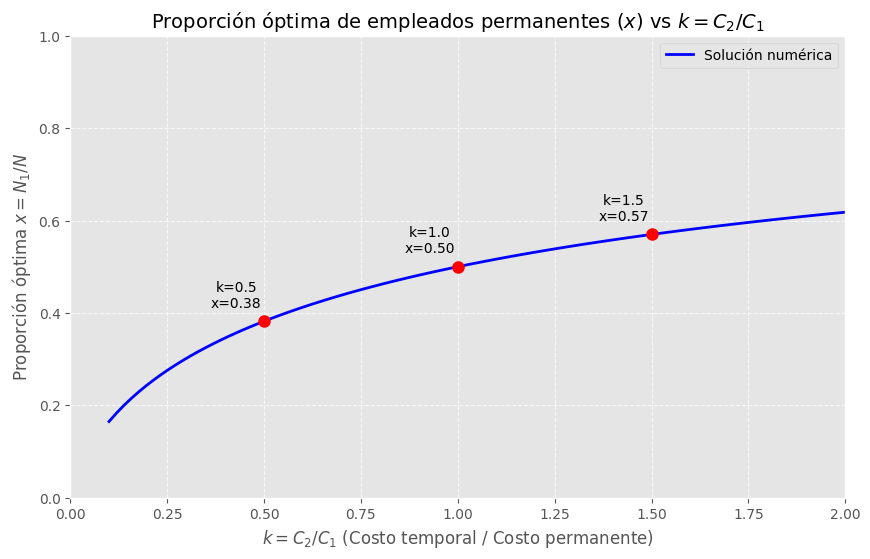

In [ ]:
# Función para resolver x^k + x - 1 = 0
def equation(x, k):
    return x**k + x - 1

# Rango de valores para k = C2/C1
k_values = np.linspace(0.1, 2.0, 100)  # Desde C2 = 0.1*C1 hasta C2 = 2*C1
x_solutions = []

# Resolver numéricamente para cada k
for k in k_values:
    # Usamos un método numérico (fsolve) para encontrar la raíz
    x_initial_guess = 0.5  # Estimación inicial
    x_sol, = fsolve(equation, x_initial_guess, args=(k,))
    x_solutions.append(x_sol)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values, x_solutions, 'b-', linewidth=2, label='Solución numérica')

# Destacar puntos clave
highlight_k = [0.5, 1.0, 1.5]
for k in highlight_k:
    x_sol, = fsolve(equation, 0.5, args=(k,))
    plt.plot(k, x_sol, 'ro', markersize=8)
    plt.annotate(f'k={k}\nx={x_sol:.2f}',
                 (k, x_sol),
                 textcoords="offset points",
                 xytext=(-20,10),
                 ha='center')

# Configuración del gráfico
plt.title('Proporción óptima de empleados permanentes ($x$) vs $k = C_2/C_1$', fontsize=14)
plt.xlabel('$k = C_2/C_1$ (Costo temporal / Costo permanente)', fontsize=12)
plt.ylabel('Proporción óptima $x = N_1/N$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 2)


El gráfico muestra cómo la proporción óptima de empleados permanentes disminuye a medida que el costo relativo de los temporales (k) aumenta, reflejando el trade-off entre minimizar costos y mantener diversidad.